# Synthetic Stratigraphy
Quick synthetic scenarios to sanity-check stratigraphy behavior and preservation metrics.

In [1]:
from pathlib import Path

import numpy as np

from bathymetry_analysis import (
    StratigraphyConfig,
    Transect,
    list_synthetic_scenarios,
    run_synthetic_scenario_by_name,
 )

cfg = StratigraphyConfig(initial_index=0, dx=5.0, target_crs="EPSG:32618")
output_root = Path.cwd() / "plots" / "python" / "stratigraphy" / "synthetic"
output_root.mkdir(parents=True, exist_ok=True)

# Single 1D transect across the full 500 m domain.
transect = Transect(
    name="T1",
    x=np.array([0.0, 500.0], dtype=float),
    y=np.array([0.0, 0.0], dtype=float),
 )

scenarios = list_synthetic_scenarios()
print("Available scenarios:")
for scenario in scenarios:
    print(f"- {scenario.name} (nsteps={scenario.nsteps}, translation={scenario.translation_m_per_year})")

Available scenarios:
- gaussian_hump_migration (nsteps=21, translation=10.0)
- gaussian_channel_migration (nsteps=21, translation=10.0)
- gaussian_channel_fill (nsteps=21, translation=0.0)
- gaussian_channel_growth (nsteps=21, translation=0.0)
- gaussian_hump_growth (nsteps=21, translation=0.0)
- gaussian_hump_erosion (nsteps=21, translation=0.0)
- gilbert_delta_ideal (nsteps=21, translation=10.0)
- accreting_flat (nsteps=21, translation=0.0)
- eroding_flat (nsteps=21, translation=0.0)
- static_flat (nsteps=21, translation=0.0)
- bruun_slr (nsteps=20, translation=0.0)


## Gaussian Hump Migration
Migrate a positive Gaussian bump to test preservation under translation.

c:\bathy2strat\code\bathymetry_analysis\stratigraphy.py:308: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


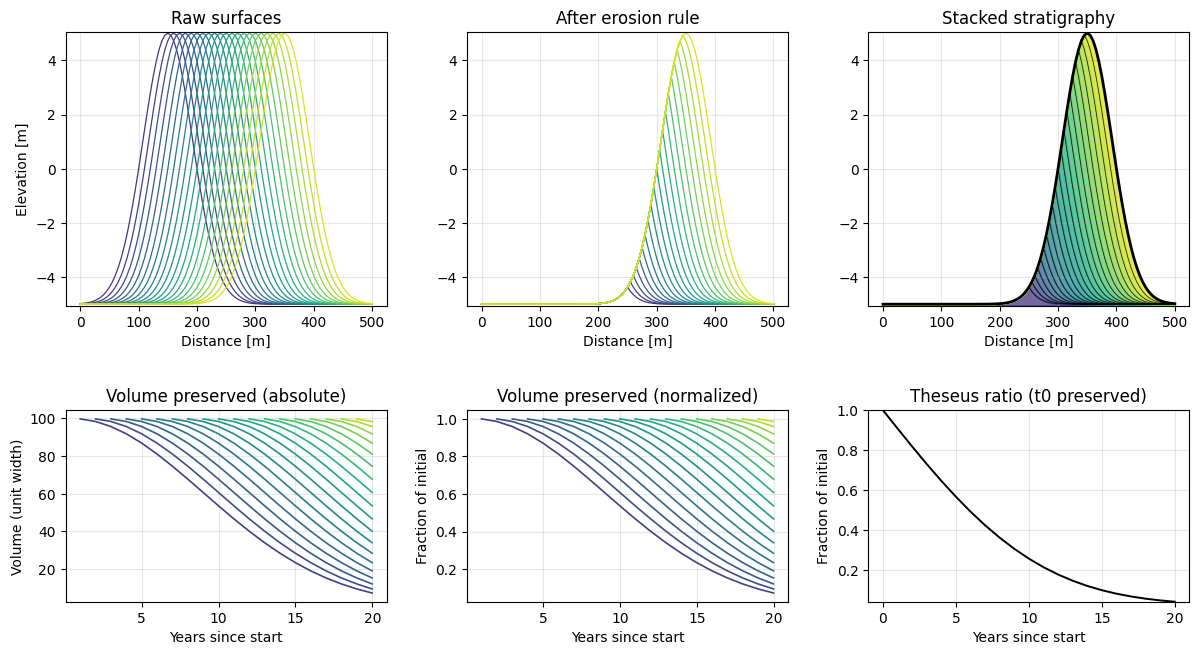

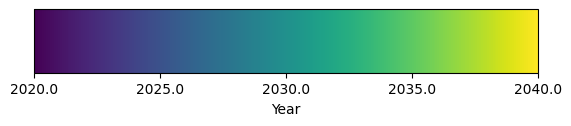

In [2]:
run_synthetic_scenario_by_name(
    "gaussian_hump_migration",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Gaussian Channel Migration
Migrate a negative Gaussian channel to test erosion-dominated preservation.

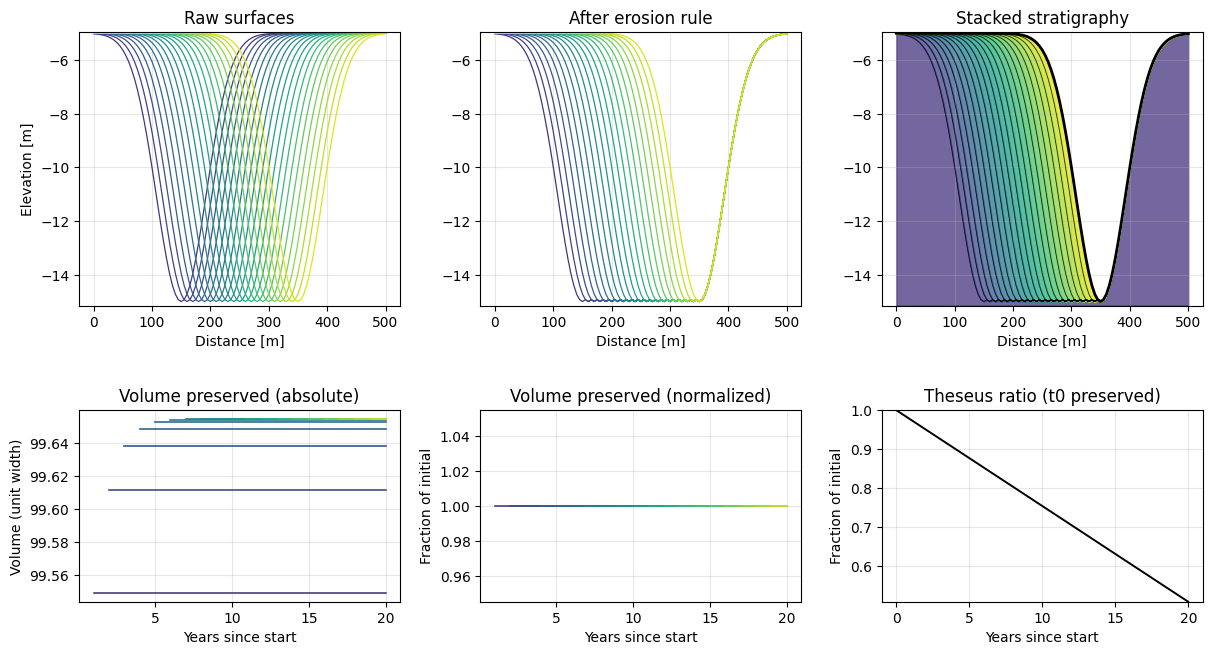

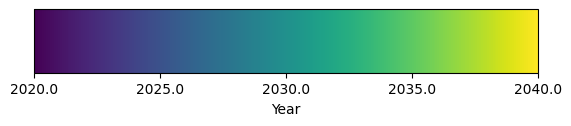

In [3]:
run_synthetic_scenario_by_name(
    "gaussian_channel_migration",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Gaussian Channel Fill
Start with a channel and fill it toward a flat bed.

c:\bathy2strat\code\bathymetry_analysis\stratigraphy.py:302: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes_bottom[2].set_ylim(ratio_min, 1.0)


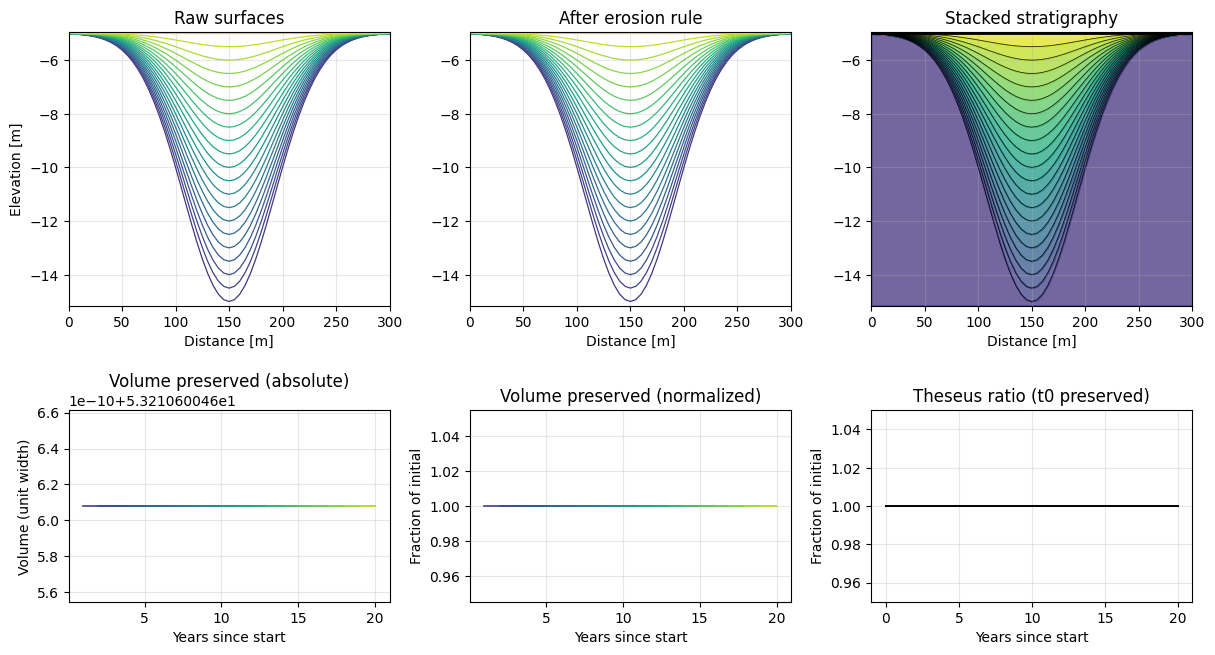

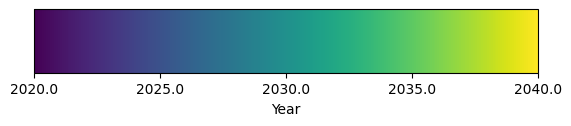

In [4]:
run_synthetic_scenario_by_name(
    "gaussian_channel_fill",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Gaussian Channel Growth
Start flat and grow a channel over time.

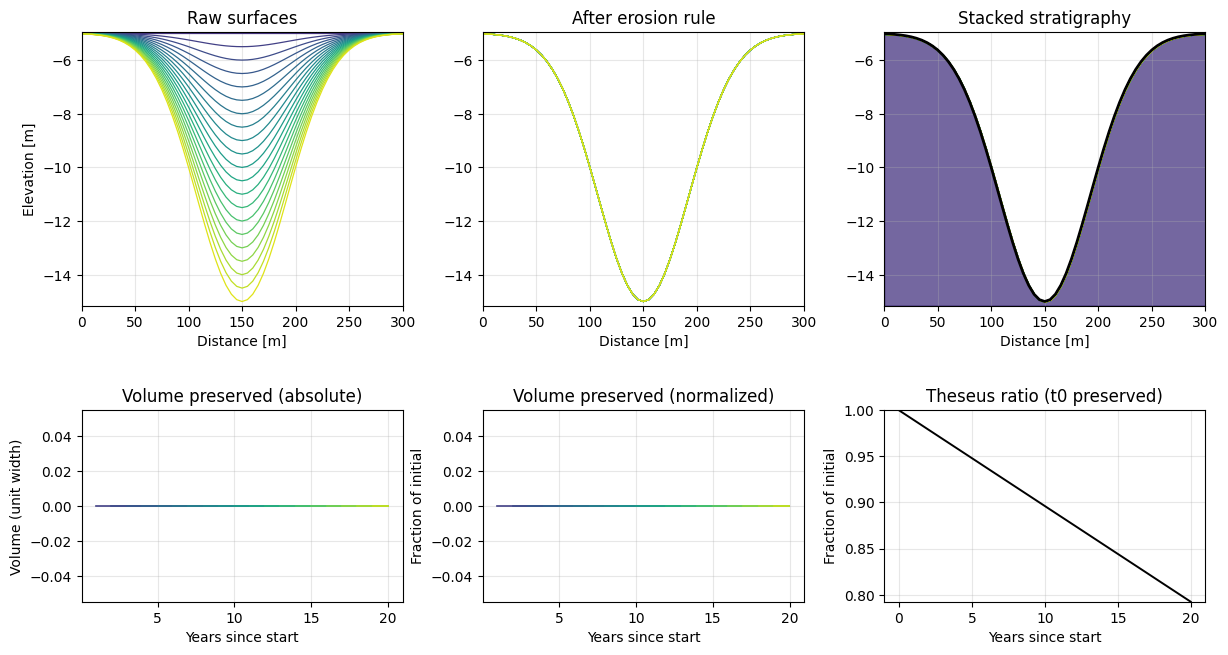

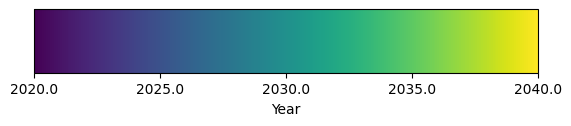

In [5]:
run_synthetic_scenario_by_name(
    "gaussian_channel_growth",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Gaussian Hump Growth
Start flat and grow a hump over time.

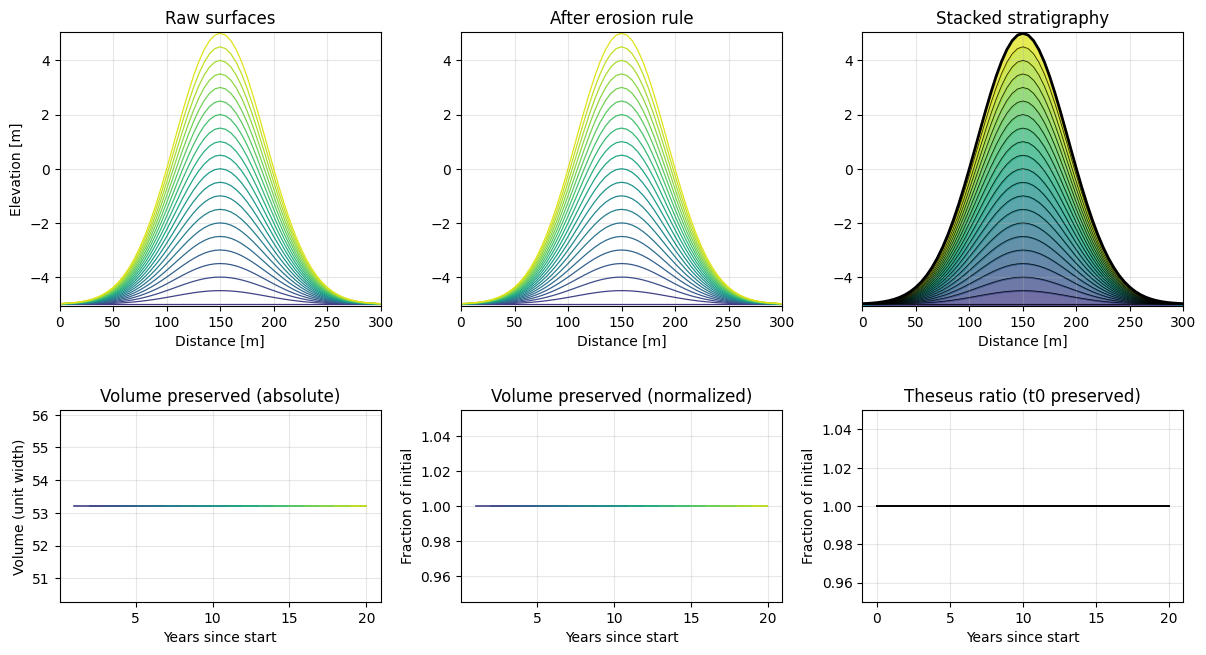

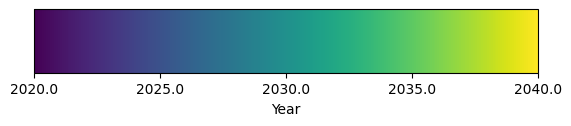

In [6]:
run_synthetic_scenario_by_name(
    "gaussian_hump_growth",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Gaussian Hump Erosion
Start with a hump and erode it toward a flat bed.

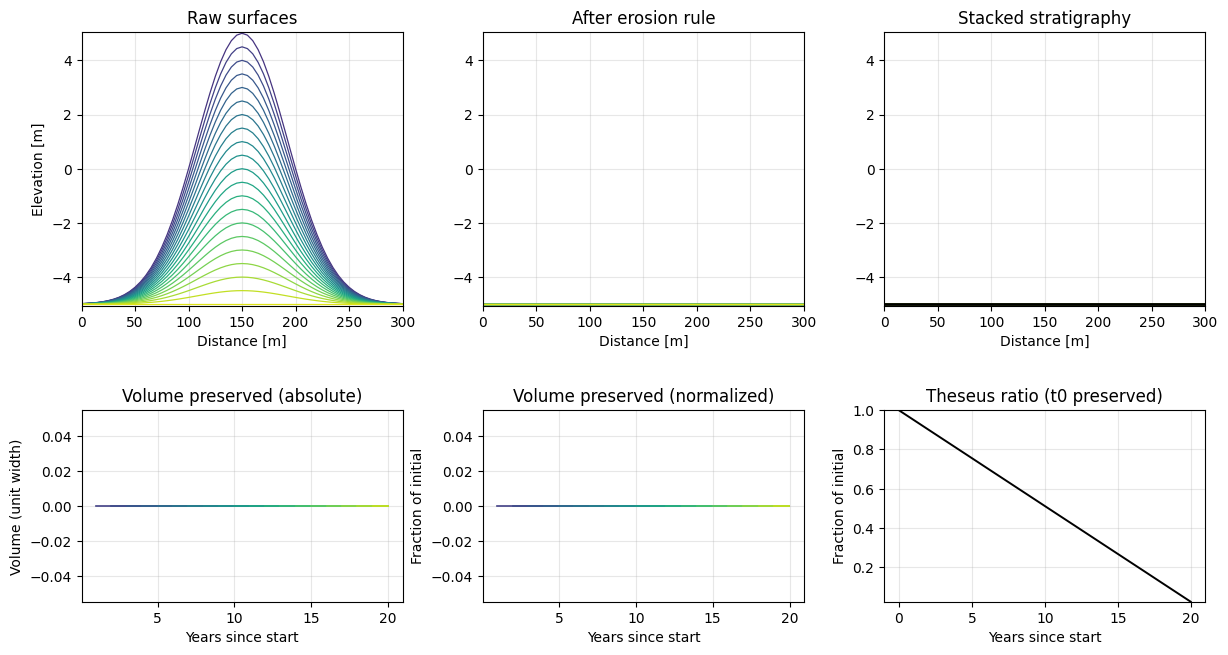

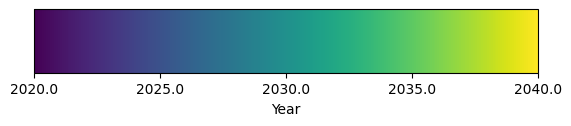

In [7]:
run_synthetic_scenario_by_name(
    "gaussian_hump_erosion",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Accreting Flat
Uniform accretion through time.

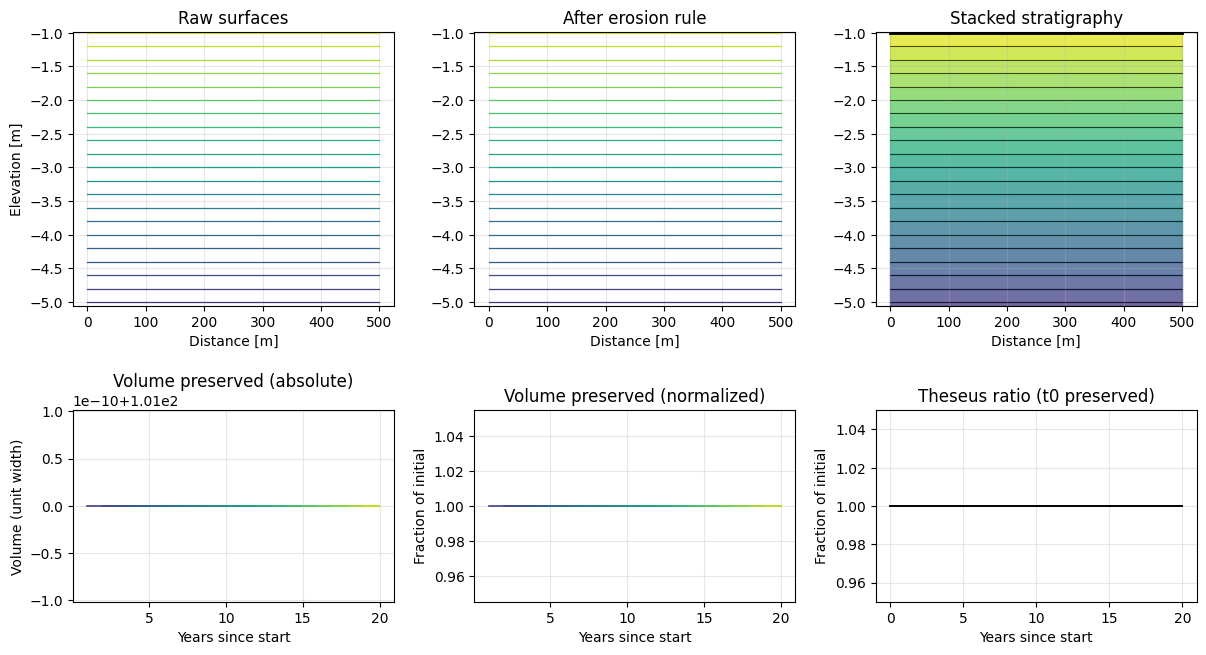

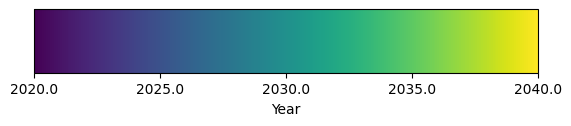

In [8]:
run_synthetic_scenario_by_name(
    "accreting_flat",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Eroding Flat
Uniform erosion through time.

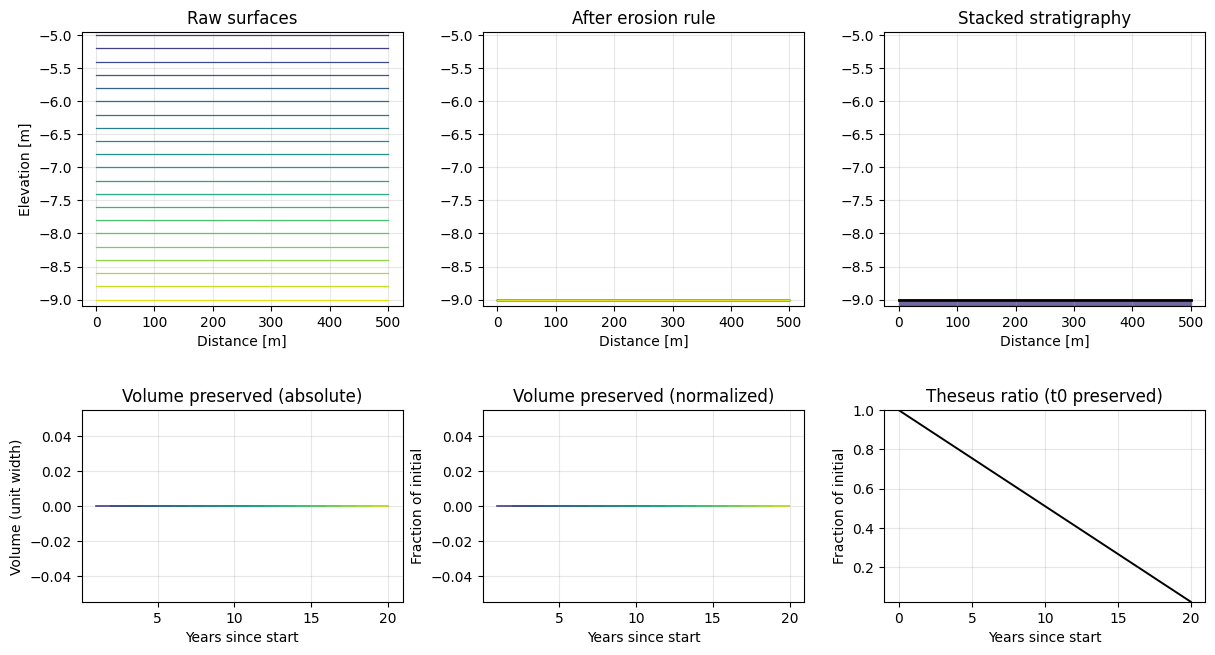

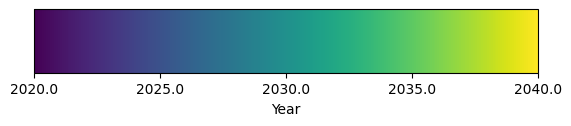

In [9]:
run_synthetic_scenario_by_name(
    "eroding_flat",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Static Flat
No change through time (baseline preservation).

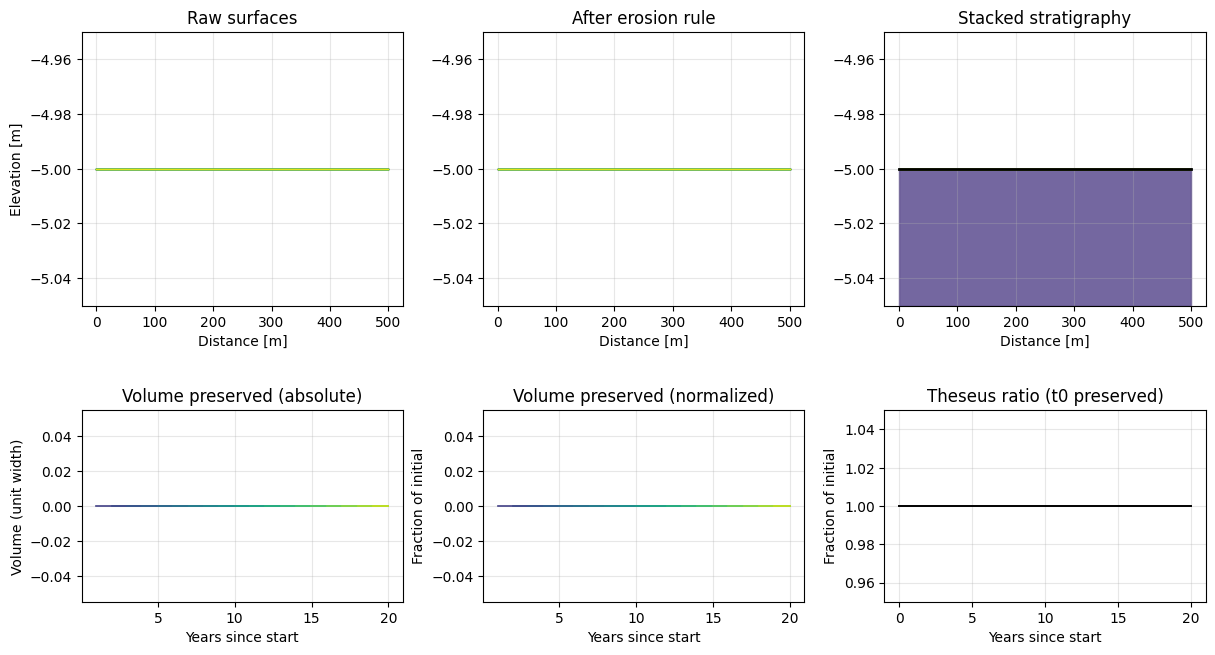

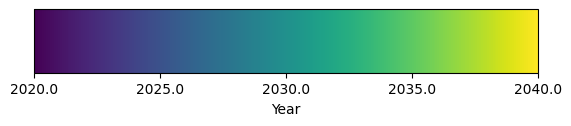

In [10]:
run_synthetic_scenario_by_name(
    "static_flat",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Gilbert Delta Ideal
Tripartite topset-foreset-bottomset with clean progradation. The synthetic domain for non‑Bruun cases is still capped at 0–500 m, so as the Gilbert delta progrades, the toe can move beyond the domain and any additional volume outside that window is not captured. That makes later deposits look smaller even though the shape itself is not steepening.

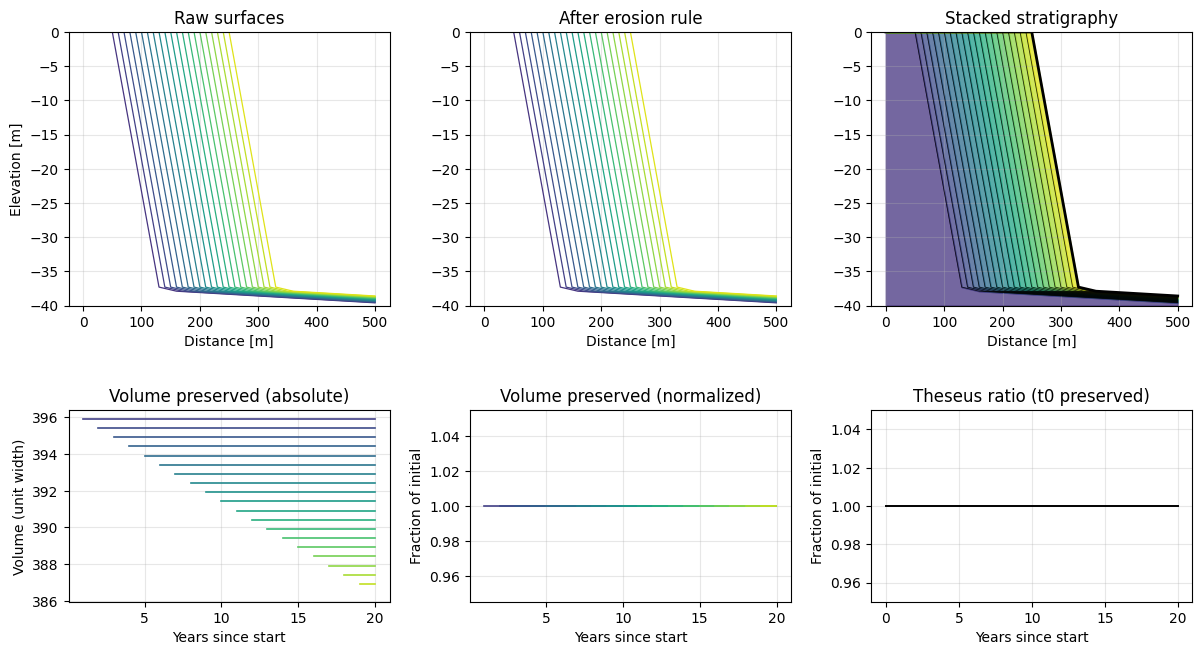

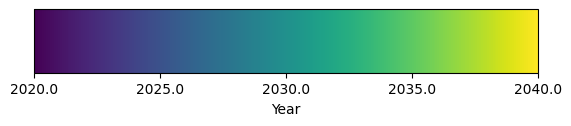

In [11]:
run_synthetic_scenario_by_name(
    "gilbert_delta_ideal",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
)

## Bruun SLR
Dean profile with Bruun-rule retreat under sea-level rise.

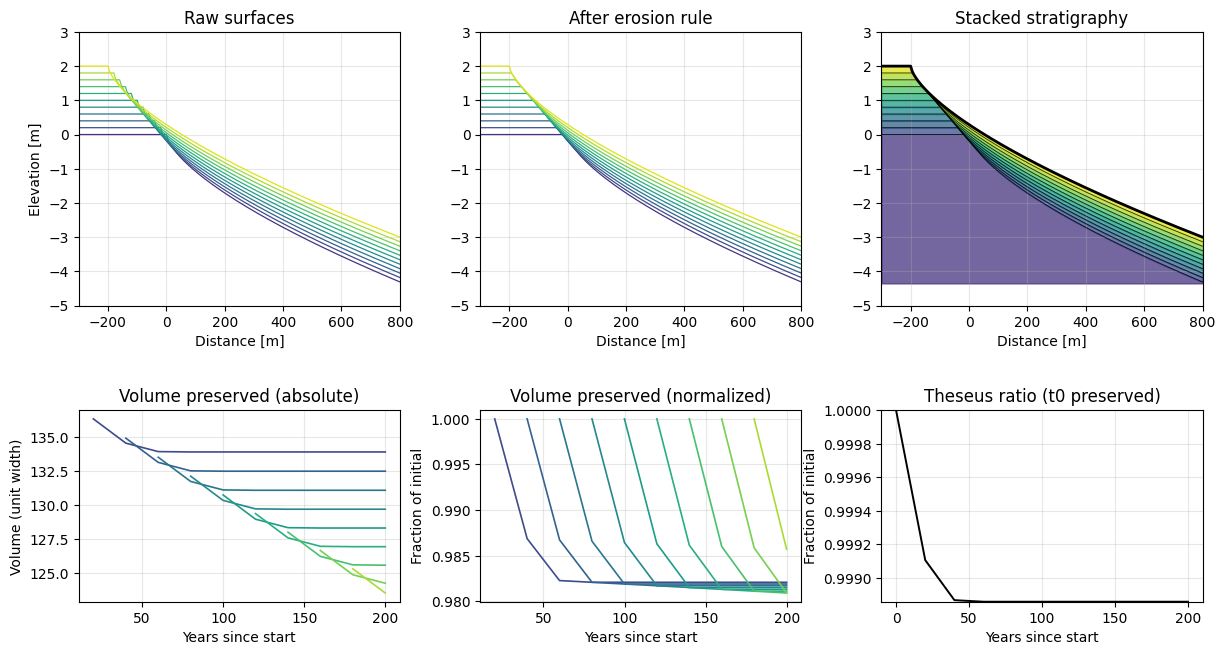

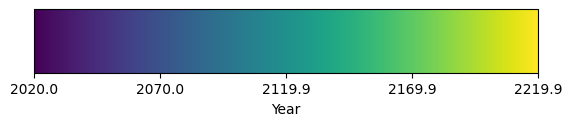

In [12]:
run_synthetic_scenario_by_name(
    "bruun_slr",
    cfg=cfg,
    output_root=output_root,
    transects=[transect],
    years_total=200.0,
    years_step=20.0,
    plot_xlim=(-300.0, 800.0),
    plot_ylim=(-5.0, 3.0),
    bruun_A=0.05,
    bruun_slr_rate=0.01,
    bruun_retreat_factor=100.0,
    bruun_m=2.0 / 3.0,
)